<a href="https://colab.research.google.com/github/fawkes12345/LNDb-Multimodal/blob/main/notebooks/01_ct_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D CT Visualization and Nodule Localization

## Goal(with the help of SimpleITK)

The goal of this notebook is to connect the metadata in `allNods.csv`
with the actual 3D CT images.

For a selected pulmonary nodule, we will:

1. load the corresponding LNDb CT scan,
2. inspect image spacing and origin,
3. convert world coordinates into voxel coordinates,
4. locate the annotated pulmonary nodule,
5. visualize the nodule in axial, coronal, and sagittal views,
6. crop a 3D nodule patch for future neural-network input.

This step establishes the image modality pipeline before constructing
the image encoder.

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/LNDb-Multimodal"
)

DATA_ROOT = PROJECT_ROOT / "data"
METADATA_DIR = DATA_ROOT / "metadata"
CT_DIR = DATA_ROOT / "ct"

CT_DIR.mkdir(parents=True, exist_ok=True)

print(CT_DIR)

Mounted at /content/drive
/content/drive/MyDrive/LNDb-Multimodal/data/ct


In [2]:
!pip install SimpleITK -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 23.2 MB/s eta 0:00:00


In [3]:
import SimpleITK as sitk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
all_nodules_df = pd.read_csv(
    METADATA_DIR / "allNods.csv"
)

example = all_nodules_df[
    (all_nodules_df["LNDbID"] == 1)
    &
    (all_nodules_df["FindingID"] == 1)
].iloc[0]

display(example)

,0
LNDbID,1
RadID,"1,2,3"
RadFinding,"1,1,1"
FindingID,1
Nodule,"1,1,1"
x,-44.203451
y,-119.073242
z,-37.5
DiamEq_Rad,7.516572
Texture,5.0


In [5]:
world_coord = (
    float(example["x"]),
    float(example["y"]),
    float(example["z"])
)

print("World coordinate:", world_coord)

World coordinate: (-44.20345052166667, -119.07324219166668, -37.5)


In [6]:
import requests

url = (
    "https://zenodo.org/records/8348419/files/"
    "trainset_csv.zip"
)

target = METADATA_DIR / "trainset_csv.zip"

r = requests.get(url)
r.raise_for_status()

with open(target, "wb") as f:
    f.write(r.content)

print(target)

/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv.zip


In [7]:
import zipfile

extract_dir = METADATA_DIR / "trainset_csv"

with zipfile.ZipFile(target, "r") as z:
    z.extractall(extract_dir)

print(list(extract_dir.iterdir())[:20])

[PosixPath('/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainNodules.csv'), PosixPath('/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainNodules_gt.csv'), PosixPath('/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainCTs.csv'), PosixPath('/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainFleischner.csv'), PosixPath('/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainFolds.csv')]


In [8]:
for p in extract_dir.rglob("*"):
    if p.is_file():
        print(p)

/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainNodules.csv
/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainNodules_gt.csv
/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainCTs.csv
/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainFleischner.csv
/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainFolds.csv


In [9]:
import pandas as pd

train_cts = pd.read_csv(
    "/content/drive/MyDrive/LNDb-Multimodal/data/metadata/trainset_csv/trainCTs.csv"
)

print("Shape:", train_cts.shape)
print("Columns:", train_cts.columns.tolist())

display(train_cts.head(20))

Shape: (236, 2)
Columns: ['LNDbID', 'RadN']


,LNDbID,RadN
0,1,3
1,2,3
2,3,3
3,4,3
4,5,3
5,7,3
6,8,3
7,10,3
8,11,3
9,13,3


In [10]:
display(
    train_cts[
        train_cts["LNDbID"] == 1
    ]
)

,LNDbID,RadN
0,1,3


In [16]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/LNDb-Multimodal"
)

CT_DIR = PROJECT_ROOT / "data" / "ct"

CT_ARCHIVE_DIR = CT_DIR / "archives"

CT_ARCHIVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(CT_ARCHIVE_DIR)

/content/drive/MyDrive/LNDb-Multimodal/data/ct/archives


In [17]:
import requests
from tqdm.auto import tqdm

url = (
    "https://zenodo.org/records/"
    "8348419/files/data0.rar"
)

target = CT_ARCHIVE_DIR / "data0.rar"

response = requests.get(
    url,
    stream=True
)

response.raise_for_status()

total_size = int(
    response.headers.get(
        "content-length",
        0
    )
)

with open(target, "wb") as f:

    with tqdm(
        total=total_size,
        unit="B",
        unit_scale=True
    ) as progress:

        for chunk in response.iter_content(
            chunk_size=1024 * 1024
        ):

            if chunk:
                f.write(chunk)
                progress.update(len(chunk))

print("Saved to:", target)

  0%|          | 0.00/4.19G [00:00<?, ?B/s]

Saved to: /content/drive/MyDrive/LNDb-Multimodal/data/ct/archives/data0.rar


In [18]:
print(
    "Exists:",
    target.exists()
)

print(
    "Size:",
    round(
        target.stat().st_size / (1024**3),
        2
    ),
    "GB"
)

Exists: True
Size: 3.9 GB


In [19]:
!apt-get update -qq
!apt-get install -y unrar

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:7.0.7-1build1).
0 upgraded, 0 newly installed, 0 to remove and 135 not upgraded.


In [20]:
archive_path = str(target)

In [21]:
!unrar lb "{archive_path}" | head -50

LNDb-0063.raw
LNDb-0001.mhd
LNDb-0001.raw
LNDb-0002.mhd
LNDb-0002.raw
LNDb-0003.mhd
LNDb-0003.raw
LNDb-0004.mhd
LNDb-0004.raw
LNDb-0005.mhd
LNDb-0005.raw
LNDb-0007.mhd
LNDb-0007.raw
LNDb-0008.mhd
LNDb-0008.raw
LNDb-0010.mhd
LNDb-0010.raw
LNDb-0011.mhd
LNDb-0011.raw
LNDb-0013.mhd
LNDb-0013.raw
LNDb-0015.mhd
LNDb-0015.raw
LNDb-0016.mhd
LNDb-0016.raw
LNDb-0017.mhd
LNDb-0017.raw
LNDb-0018.mhd
LNDb-0018.raw
LNDb-0020.mhd
LNDb-0020.raw
LNDb-0021.mhd
LNDb-0021.raw
LNDb-0022.mhd
LNDb-0022.raw
LNDb-0024.mhd
LNDb-0024.raw
LNDb-0025.mhd
LNDb-0025.raw
LNDb-0026.mhd
LNDb-0026.raw
LNDb-0028.mhd
LNDb-0028.raw
LNDb-0031.mhd
LNDb-0031.raw
LNDb-0034.mhd
LNDb-0034.raw
LNDb-0035.mhd
LNDb-0035.raw
LNDb-0037.mhd


In [22]:
!unrar lb "{archive_path}" | grep "LNDb-0001"

LNDb-0001.mhd
LNDb-0001.raw


In [23]:
CASE_DIR = (
    CT_DIR
    / "cases"
    / "LNDb-0001"
)

CASE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

case_dir_str = str(CASE_DIR)

In [24]:
!unrar e "{archive_path}" "LNDb-0001.mhd" "{case_dir_str}/"
!unrar e "{archive_path}" "LNDb-0001.raw" "{case_dir_str}/"


UNRAR 7.00 freeware      Copyright (c) 1993-2024 Alexander Roshal


Extracting from /content/drive/MyDrive/LNDb-Multimodal/data/ct/archives/data0.rar

Extracting  /content/drive/MyDrive/LNDb-Multimodal/data/ct/cases/LNDb-0001/LNDb-0001.mhd       2%  OK 
All OK

UNRAR 7.00 freeware      Copyright (c) 1993-2024 Alexander Roshal


Extracting from /content/drive/MyDrive/LNDb-Multimodal/data/ct/archives/data0.rar

Extracting  /content/drive/MyDrive/LNDb-Multimodal/data/ct/cases/LNDb-0001/LNDb-0001.raw       2%  3%  4%  OK 
All OK


# .mhd
保存了
size
spacing
origin
direction
raw filename
# .raw
保存了真正的 3D CT 数值

In [25]:
!pip install SimpleITK -q

这是一个可以帮我们方便处理CT影像数据的工具

In [26]:
import SimpleITK as sitk

In [27]:
ct_path = (
    CASE_DIR
    / "LNDb-0001.mhd"
)

ct_image = sitk.ReadImage(
    str(ct_path)
)

In [28]:
print(
    "Size:",
    ct_image.GetSize()
)

print(
    "Spacing:",
    ct_image.GetSpacing()
)

print(
    "Origin:",
    ct_image.GetOrigin()
)

print(
    "Direction:",
    ct_image.GetDirection()
)

Size: (512, 512, 328)
Spacing: (0.607421875, 0.607421875, 1.0)
Origin: (-158.1962890625, -309.1962890625, -297.5)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


这个 3D CT 有多大？
每个 voxel 多大？
第一个 voxel 在真实世界哪里？
图像坐标方向是什么？

In [29]:
example = all_nodules_df[
    (all_nodules_df["LNDbID"] == 1)
    &
    (all_nodules_df["FindingID"] == 1)
].iloc[0]

world_coord = (
    float(example["x"]),
    float(example["y"]),
    float(example["z"])
)

print(world_coord)

(-44.20345052166667, -119.07324219166668, -37.5)


读取之前的world coordinate

# World Coordinate → Voxel Index

In [30]:
voxel_index = (
    ct_image
    .TransformPhysicalPointToIndex(
        world_coord
    )
)

print(
    "Voxel index:",
    voxel_index
)

Voxel index: (188, 313, 260)


In [31]:
import numpy as np

ct_array = sitk.GetArrayFromImage(
    ct_image
)

print(
    ct_array.shape
)

(328, 512, 512)


SimpleITK index:
(x, y, z)

NumPy array:
[z, y, x]

In [32]:
i, j, k = voxel_index

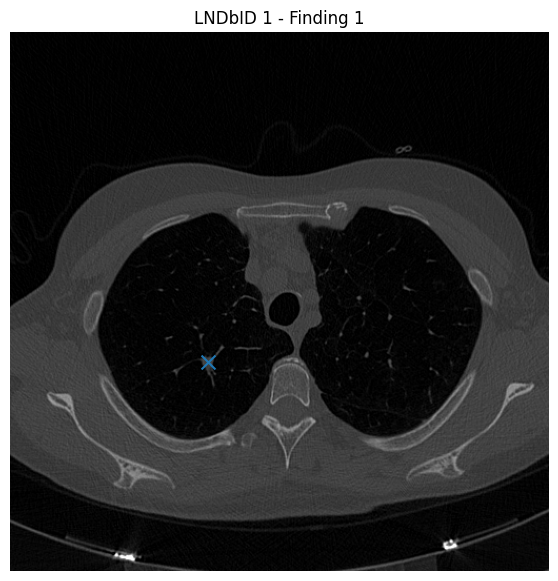

In [33]:
import matplotlib.pyplot as plt

i, j, k = voxel_index

axial_slice = ct_array[
    k,
    :,
    :
]

plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    axial_slice,
    cmap="gray"
)

plt.scatter(
    i,
    j,
    marker="x",
    s=100
)

plt.title(
    "LNDbID 1 - Finding 1"
)

plt.axis("off")

plt.show()

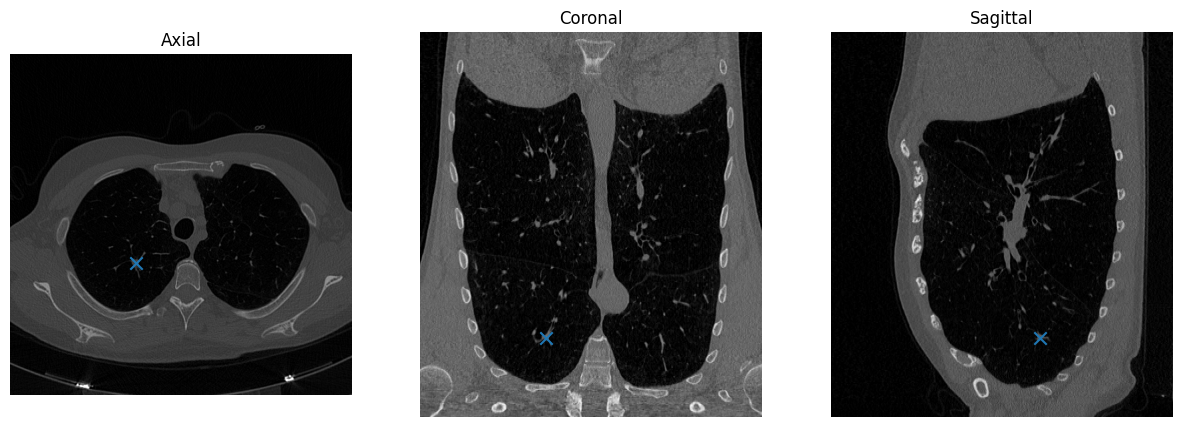

In [34]:
i, j, k = voxel_index

axial = ct_array[k, :, :]
coronal = ct_array[:, j, :]
sagittal = ct_array[:, :, i]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(axial, cmap="gray")
axes[0].scatter(i, j, marker="x", s=80)
axes[0].set_title("Axial")

axes[1].imshow(coronal, cmap="gray", aspect="auto")
axes[1].scatter(i, k, marker="x", s=80)
axes[1].set_title("Coronal")

axes[2].imshow(sagittal, cmap="gray", aspect="auto")
axes[2].scatter(j, k, marker="x", s=80)
axes[2].set_title("Sagittal")

for ax in axes:
    ax.axis("off")

plt.show()

In [35]:
half = 32

z_min = max(k - half, 0)
z_max = min(k + half, ct_array.shape[0])

y_min = max(j - half, 0)
y_max = min(j + half, ct_array.shape[1])

x_min = max(i - half, 0)
x_max = min(i + half, ct_array.shape[2])

crop = ct_array[
    z_min:z_max,
    y_min:y_max,
    x_min:x_max
]

print("Crop shape:", crop.shape)

Crop shape: (64, 64, 64)


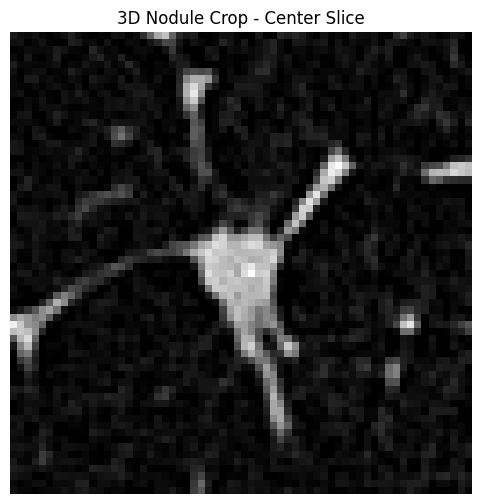

In [36]:
mid_z = crop.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(crop[mid_z], cmap="gray")
plt.title("3D Nodule Crop - Center Slice")
plt.axis("off")
plt.show()